<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_4_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=gEoWMLXk0Ys) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part04.pdf)

In [1]:
# Week 2, Lecture 4: Feature Detectors : SIFT and Variants
from IPython.display import HTML, display

VIDEO_ID = "gEoWMLXk0Ys"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 2, Lecture 4: SIFT and Variants

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§2.4 Feature Detectors: SIFT and Variants**.

**What you will learn**

- Work through the four stages of **SIFT**: scale-space extrema, keypoint localization, orientation, descriptor.
- Understand what makes the descriptor invariant to scale and rotation.
- Use SIFT for **matching** and for **image stitching**.
- Compare the variants: **SURF, MOPS and GLOH**.

**Contents**
1. The four stages of SIFT
2. Step 1: Scale-space extrema detection
3. Step 2: Keypoint localization
4. Step 3: Orientation estimation
5. Step 4: Keypoint descriptor
6. SIFT in practice
7. Application: matching and stitching
8. Variants: SURF, MOPS and GLOH

**How to run**  Runs on Colab or a local Jupyter, CPU only. Needs `opencv-python` alongside `scikit-image` and `scipy`; Colab ships all three. Run the setup cell first, then go top to bottom.

## Review

The previous lecture built scale space, the Gaussian and Laplacian pyramids, and filter banks. Those tools answered *how* to process an image across scales. This lecture uses them to build a full detector and descriptor.

**SIFT** (Scale Invariant Feature Transform, Lowe 2004) turns an image into a set of local keypoints, each carrying a location, a scale, an orientation, and a 128-dimensional descriptor. The descriptors are built to be invariant to translation, rotation and scale, and robust to illumination and small viewpoint change, so the same physical point produces nearly the same descriptor in two different images. That property is what makes matching, stitching and recognition possible.

## Setup

Everything runs offline on images bundled with `scikit-image`, plus a few synthetic patterns. OpenCV provides a reference SIFT implementation that we call once the individual stages are clear.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, util, color
import cv2

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image):
    return color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)

def show(ax, im, title='', cmap='gray'):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis('off')

def to_u8(im):                                  # float image in [0,1] to uint8 for OpenCV
    return (np.clip(im, 0, 1) * 255).astype(np.uint8)

## 1. The four stages of SIFT

SIFT is a pipeline. Each stage narrows a large pool of candidates into a small set of stable, well described keypoints.

1. **Scale-space extrema detection.** Search over location and scale for candidate points, using the Difference of Gaussians.
2. **Keypoint localization.** Refine each candidate to sub-pixel and sub-scale accuracy, then discard low contrast points and points on edges.
3. **Orientation estimation.** Assign a dominant gradient orientation to each keypoint, which is what makes the descriptor rotation invariant.
4. **Keypoint descriptor.** Summarize the gradients around the keypoint into a 128-dimensional vector that is robust to illumination and small deformation.

The next sections build each stage in turn.

## 2. Step 1: Scale-space extrema detection

To find structures of every size, the image is smoothed at a geometric sequence of scales. Within one **octave** the scale grows by a factor $k$ per level,

$$
\hat I(x, y, \sigma) = G(x, y, \sigma) * I(x, y),
\qquad
\sigma_{\ell} = \sigma_0 \, k^{\ell}.
$$

The **Difference of Gaussians** subtracts adjacent levels,

$$
D(x, y, \sigma) = \hat I(x, y, \sigma) - \hat I(x, y, k\sigma).
$$

The DoG is cheap to compute and closely approximates the scale-normalized Laplacian of Gaussian, because

$$
G(x, y, k\sigma) - G(x, y, \sigma) \approx (k - 1)\, \sigma^2 \, \nabla^2 G .
$$

A **keypoint candidate** is a pixel in the DoG stack that is a strict maximum or minimum of its $3 \times 3 \times 3$ neighborhood: the 8 neighbors in its own scale plus the 9 in each adjacent scale, 26 in total.

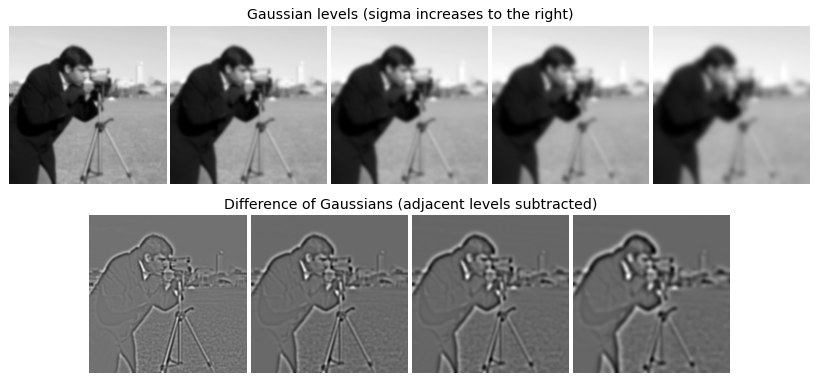

In [3]:
# one octave: Gaussian-smoothed levels and their successive differences
def gaussian_levels(im, sigma0, k, n):
    return [ndi.gaussian_filter(im, sigma0 * k**i) for i in range(n)]

def montage(levels, pad=4):                     # lay levels side by side, each rescaled to [0,1]
    H = max(p.shape[0] for p in levels)
    W = sum(p.shape[1] for p in levels) + pad * len(levels)
    canvas = np.full((H, W), np.nan)
    x = 0
    for p in levels:
        p = (p - p.min()) / (np.ptp(p) + 1e-9)
        h, w = p.shape; canvas[:h, x:x + w] = p; x += w + pad
    return canvas

img = load_gray(data.camera())[::2, ::2]        # 256 x 256
k = 2 ** (1 / 3)
G   = gaussian_levels(img, 1.6, k, 5)
DoG = [G[i] - G[i + 1] for i in range(4)]

fig, ax = plt.subplots(2, 1, figsize=(13, 4.6))
show(ax[0], montage(G),   'Gaussian levels (sigma increases to the right)')
show(ax[1], montage(DoG), 'Difference of Gaussians (adjacent levels subtracted)')
plt.tight_layout(); plt.show()

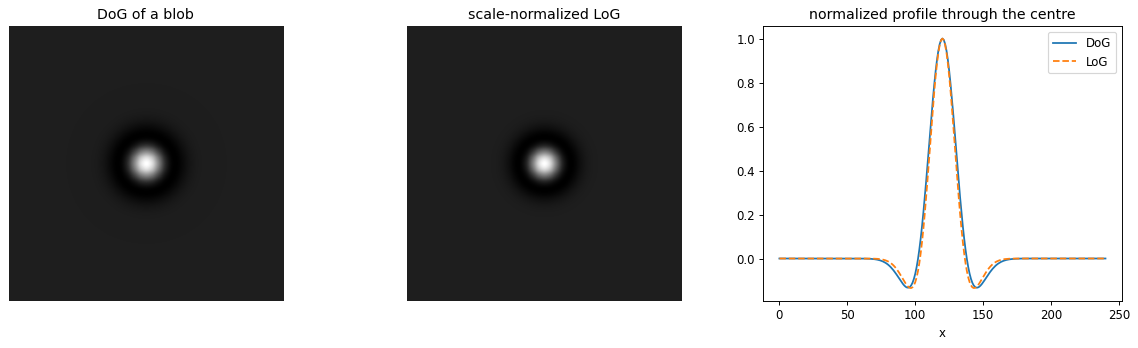

In [4]:
# DoG closely approximates the scale-normalized LoG
n = 241; c = n // 2
yy, xx = np.mgrid[0:n, 0:n]
blob = np.exp(-((xx - c)**2 + (yy - c)**2) / (2 * 10.0**2))
sigma = 6.0
dog = ndi.gaussian_filter(blob, sigma) - ndi.gaussian_filter(blob, 1.6 * sigma)
log = -sigma**2 * ndi.gaussian_laplace(blob, sigma)      # negate so a bright centre is positive

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
show(ax[0], dog, 'DoG of a blob')
show(ax[1], log, 'scale-normalized LoG')
ax[2].plot(dog[c] / np.abs(dog[c]).max(), label='DoG')
ax[2].plot(log[c] / np.abs(log[c]).max(), '--', label='LoG')
ax[2].set_title('normalized profile through the centre'); ax[2].set_xlabel('x'); ax[2].legend()
plt.tight_layout(); plt.show()

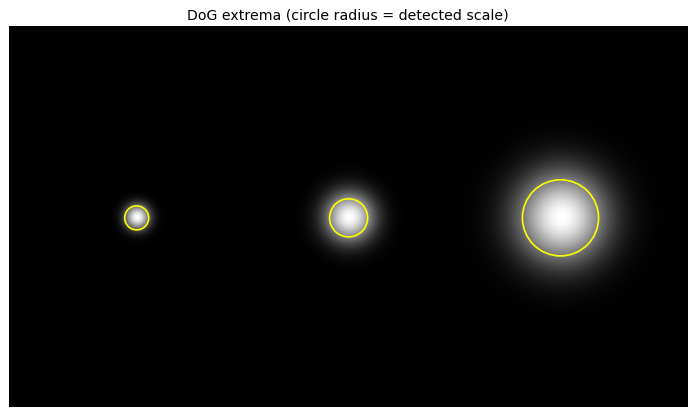

3 extrema over 11 DoG levels; larger blobs are detected at larger scales


In [5]:
# blobs of three sizes: detect DoG extrema across scale, draw each at its recovered scale
canvas = np.zeros((180, 320))
blobs = [(60, 90, 6), (160, 90, 12), (260, 90, 22)]
for cx, cy, r in blobs:
    canvas += np.exp(-(((np.arange(320)[None, :] - cx)**2 +
                        (np.arange(180)[:, None] - cy)**2) / (2 * (r / 1.5)**2)))

sigmas = [2.0 * (2 ** (1 / 3))**i for i in range(12)]
levels = [ndi.gaussian_filter(canvas, s) for s in sigmas]
D = np.stack([levels[i] - levels[i + 1] for i in range(len(levels) - 1)])   # (scales, H, W)

# 26-neighbour test = strict max or min inside a 3 x 3 x 3 window
is_ext = ((D == ndi.maximum_filter(D, size=(3, 3, 3))) |
          (D == ndi.minimum_filter(D, size=(3, 3, 3)))) & (np.abs(D) > 0.03)
is_ext[0] = is_ext[-1] = False                  # drop the boundary scales
s_idx, ys, xs = np.where(is_ext)

fig, ax = plt.subplots(figsize=(9, 5))
show(ax, canvas, 'DoG extrema (circle radius = detected scale)')
for s, y, x in zip(s_idx, ys, xs):
    ax.add_patch(plt.Circle((x, y), sigmas[s] * np.sqrt(2), color='yellow', fill=False, lw=1.4))
plt.tight_layout(); plt.show()
print(f'{len(xs)} extrema over {len(sigmas) - 1} DoG levels; larger blobs are detected at larger scales')

## 3. Step 2: Keypoint localization

The extrema above sit on the integer sampling grid, but the true extremum lies between samples. SIFT fits a quadratic to the DoG around each candidate and solves for the offset. With $\mathbf{s} = (x, y, \sigma)$, expanding $D$ to second order about a sample $\mathbf{s}_0$,

$$
D(\mathbf{s}_0 + \Delta\mathbf{s}) = D(\mathbf{s}_0) + \frac{\partial D}{\partial \mathbf{s}}^{\!\top} \Delta\mathbf{s} + \tfrac{1}{2}\, \Delta\mathbf{s}^{\top} \frac{\partial^2 D}{\partial \mathbf{s}^2}\, \Delta\mathbf{s},
$$

and setting the derivative to zero gives the sub-pixel, sub-scale offset

$$
\hat{\mathbf{s}} = -\left( \frac{\partial^2 D}{\partial \mathbf{s}^2} \right)^{-1} \frac{\partial D}{\partial \mathbf{s}}.
$$

Two tests then prune the candidates.

- **Low contrast.** Reject if $|D(\hat{\mathbf{s}})|$ falls below a threshold (Lowe uses $0.03$ on values normalized to $[0, 1]$).
- **Edge response.** A DoG extremum along an edge is poorly localized in the direction of the edge. Using the $2 \times 2$ spatial Hessian $H$ with eigenvalues $\alpha \ge \beta$ and ratio $r = \alpha / \beta$,

$$
\frac{\mathrm{Tr}(H)^2}{\det(H)} = \frac{(\alpha + \beta)^2}{\alpha\beta} = \frac{(r + 1)^2}{r}.
$$

This ratio is smallest when $r = 1$ (a corner-like point where both curvatures match) and grows as the point becomes edge-like. Reject if it exceeds $(r_{\text{th}} + 1)^2 / r_{\text{th}}$, with $r_{\text{th}} = 10$ in the original paper.

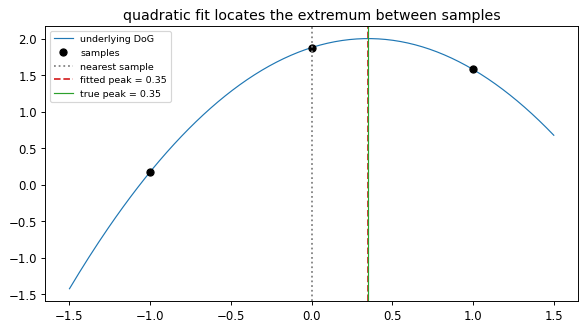

In [6]:
# sub-pixel refinement in 1D: a parabola through three samples recovers the true peak
true_peak = 0.35
f  = lambda x: -(x - true_peak)**2 + 2.0
xs = np.array([-1.0, 0.0, 1.0]); ys = f(xs)
offset = 0.5 * (ys[0] - ys[2]) / (ys[0] - 2 * ys[1] + ys[2])    # vertex of the fitted parabola

grid = np.linspace(-1.5, 1.5, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, f(grid), 'C0', lw=1, label='underlying DoG')
ax.plot(xs, ys, 'ko', label='samples')
ax.axvline(0,         color='gray', ls=':',  label='nearest sample')
ax.axvline(offset,    color='C3',   ls='--', label=f'fitted peak = {offset:.2f}')
ax.axvline(true_peak, color='C2',   ls='-', lw=1, label=f'true peak = {true_peak}')
ax.set_title('quadratic fit locates the extremum between samples'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

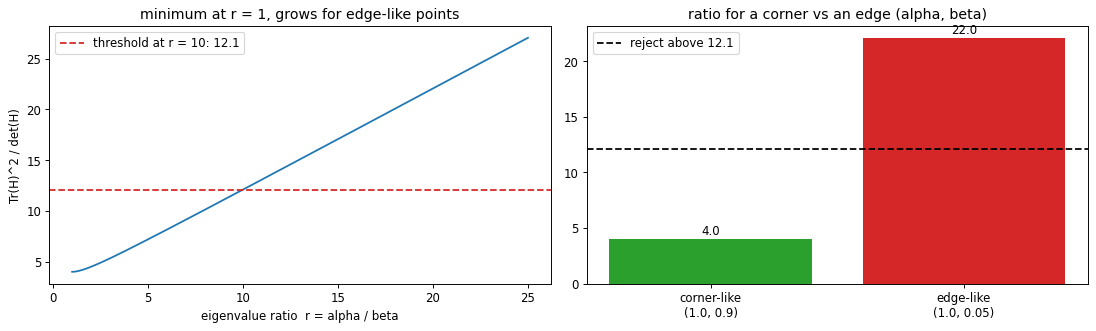

In [7]:
# the edge-rejection ratio, and two controlled examples
def edge_ratio(alpha, beta):                    # Tr(H)^2 / det(H) from the two eigenvalues
    H = np.diag([alpha, beta]); return np.trace(H)**2 / np.linalg.det(H)

r = np.linspace(1, 25, 200)
r_th = 10; thresh = (r_th + 1)**2 / r_th

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(r, (r + 1)**2 / r)
ax[0].axhline(thresh, color='C3', ls='--', label=f'threshold at r = {r_th}: {thresh:.1f}')
ax[0].set_xlabel('eigenvalue ratio  r = alpha / beta'); ax[0].set_ylabel('Tr(H)^2 / det(H)')
ax[0].set_title('minimum at r = 1, grows for edge-like points'); ax[0].legend()

cases = {'corner-like\n(1.0, 0.9)': (1.0, 0.9), 'edge-like\n(1.0, 0.05)': (1.0, 0.05)}
vals  = [edge_ratio(a, b) for a, b in cases.values()]
bars  = ax[1].bar(list(cases.keys()), vals, color=['C2', 'C3'])
ax[1].axhline(thresh, color='k', ls='--', label=f'reject above {thresh:.1f}')
ax[1].set_title('ratio for a corner vs an edge (alpha, beta)'); ax[1].legend()
for b, v in zip(bars, vals):
    ax[1].text(b.get_x() + b.get_width() / 2, v + 0.4, f'{v:.1f}', ha='center')
plt.tight_layout(); plt.show()

## 4. Step 3: Orientation estimation

Assigning each keypoint a reference orientation is what makes the descriptor rotation invariant: the descriptor is measured relative to this orientation, so rotating the image rotates the reference by the same amount and leaves the descriptor unchanged.

At the keypoint scale, the gradient magnitude and orientation are

$$
m(x, y) = \sqrt{\big(\hat I_{x+1} - \hat I_{x-1}\big)^2 + \big(\hat I_{y+1} - \hat I_{y-1}\big)^2},
$$

$$
\theta(x, y) = \operatorname{atan2}\!\big(\hat I_{y+1} - \hat I_{y-1},\; \hat I_{x+1} - \hat I_{x-1}\big).
$$

A 36-bin histogram of orientations (10 degrees per bin) is built over a region around the keypoint, each vote weighted by its gradient magnitude and by a Gaussian of width $1.5$ times the keypoint scale. The **peak** is the keypoint orientation. Any other peak within **80 percent** of the maximum adds a second keypoint at the same location with that orientation.

/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


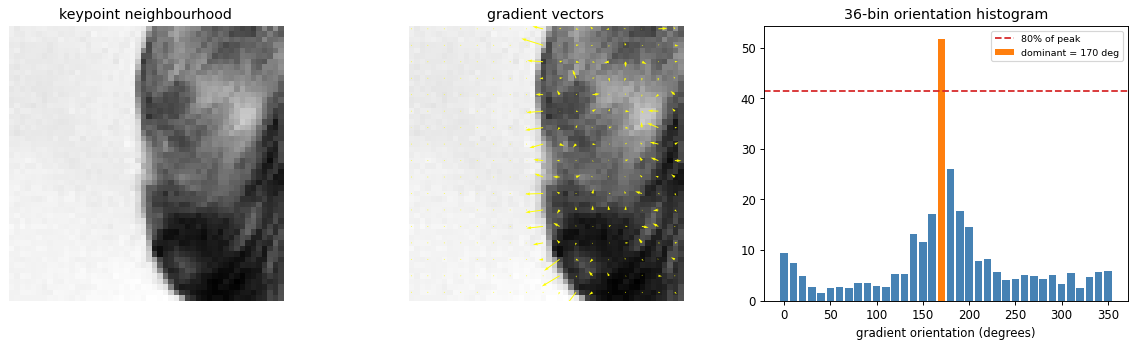

In [8]:
# gradient orientation histogram of a keypoint neighbourhood
def grad_mag_ori(patch):
    gx = ndi.sobel(patch, axis=1); gy = ndi.sobel(patch, axis=0)
    return np.hypot(gx, gy), np.rad2deg(np.arctan2(gy, gx)) % 360

def ori_histogram(patch, nbins=36, sigma=None):
    mag, ang = grad_mag_ori(patch)
    if sigma:                                   # Gaussian weighting centred on the keypoint
        cy, cx = (np.array(patch.shape) - 1) / 2
        yy, xx = np.mgrid[0:patch.shape[0], 0:patch.shape[1]]
        mag = mag * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
    h = np.zeros(nbins)
    np.add.at(h, (ang // (360 / nbins)).astype(int) % nbins, mag)
    return h

patch = load_gray(data.astronaut())[60:110, 130:180]
mag, ang = grad_mag_ori(patch)
h    = ori_histogram(patch, sigma=patch.shape[0] / 3)
peak = h.argmax()

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
show(ax[0], patch, 'keypoint neighbourhood')

step = 3
yy, xx = np.mgrid[0:patch.shape[0]:step, 0:patch.shape[1]:step]
ax[1].imshow(patch); ax[1].axis('off'); ax[1].set_title('gradient vectors')
ax[1].quiver(xx, yy,  (mag * np.cos(np.deg2rad(ang)))[::step, ::step],
                     -(mag * np.sin(np.deg2rad(ang)))[::step, ::step], color='yellow', scale=20)

bins = np.arange(36) * 10
ax[2].bar(bins, h, width=8, color='steelblue')
ax[2].bar(bins[peak], h[peak], width=8, color='C1', label=f'dominant = {peak * 10} deg')
ax[2].axhline(0.8 * h.max(), color='C3', ls='--', label='80% of peak')
ax[2].set_xlabel('gradient orientation (degrees)'); ax[2].set_title('36-bin orientation histogram'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

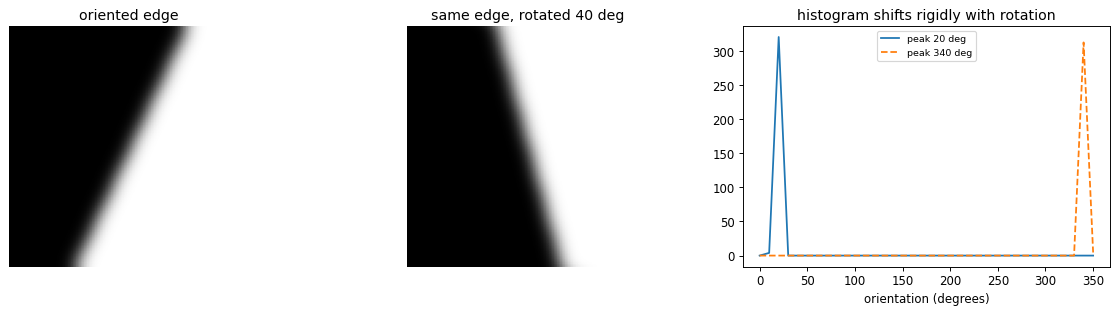

In [9]:
# rotating the patch shifts the whole histogram, so re-referencing to the peak cancels rotation
def step_patch(N, theta_deg):                   # smoothed oriented edge: one clean gradient direction
    t = np.deg2rad(theta_deg); yy, xx = np.mgrid[0:N, 0:N]
    u = (xx - N / 2) * np.cos(t) + (yy - N / 2) * np.sin(t)
    return ndi.gaussian_filter((u > 0).astype(float), 3)

base = step_patch(90, 25)
rot  = ndi.rotate(base, 40, reshape=False, order=1, mode='reflect')
c = 45; crop = lambda p: p[c - 28:c + 28, c - 28:c + 28]
h0 = ori_histogram(crop(base), sigma=18)
h1 = ori_histogram(crop(rot),  sigma=18)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
show(ax[0], base, 'oriented edge'); show(ax[1], rot, 'same edge, rotated 40 deg')
bins = np.arange(36) * 10
ax[2].plot(bins, h0, label=f'peak {h0.argmax() * 10} deg')
ax[2].plot(bins, h1, '--', label=f'peak {h1.argmax() * 10} deg')
ax[2].set_xlabel('orientation (degrees)'); ax[2].set_title('histogram shifts rigidly with rotation'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Step 4: Keypoint descriptor

The descriptor summarizes the gradients in a window around the keypoint, measured at the keypoint scale and relative to the keypoint orientation.

- Take a $16 \times 16$ window and weight the gradient magnitudes by a Gaussian centred on the keypoint, so distant pixels contribute less.
- Split the window into a $4 \times 4$ grid of cells. In each cell build an 8-bin orientation histogram.
- Concatenate the $4 \times 4 \times 8 = 128$ values into one vector.
- Normalize to unit length, clip every entry to $0.2$, then renormalize. The unit norm removes contrast and gain; the clip limits the effect of a few very large gradients.

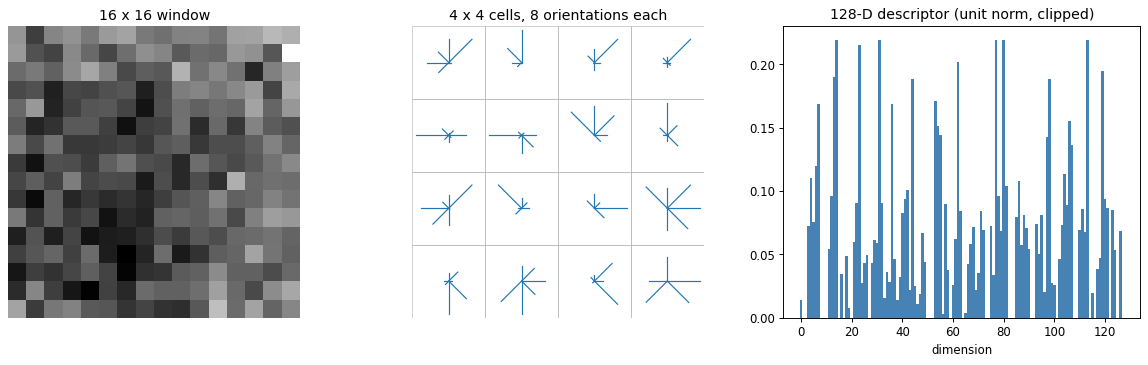

descriptor length 128   norm 1.0


In [10]:
def sift_descriptor(win16, nbins=8):
    """4x4 grid of 8-bin gradient histograms over a 16x16 window -> 128-vector."""
    gx = ndi.sobel(win16, axis=1); gy = ndi.sobel(win16, axis=0)
    mag = np.hypot(gx, gy); ang = np.rad2deg(np.arctan2(gy, gx)) % 360
    yy, xx = np.mgrid[0:16, 0:16]
    mag = mag * np.exp(-((xx - 7.5)**2 + (yy - 7.5)**2) / (2 * 8.0**2))     # Gaussian window
    cells = np.zeros((4, 4, nbins))
    for i in range(16):
        for j in range(16):
            b = int(ang[i, j] // (360 / nbins)) % nbins
            cells[i // 4, j // 4, b] += mag[i, j]
    v = cells.ravel()
    v = v / (np.linalg.norm(v) + 1e-8)          # unit norm removes contrast and gain
    v = np.clip(v, 0, 0.2)                       # limit dominant gradients
    v = v / (np.linalg.norm(v) + 1e-8)          # renormalize
    return v, cells

win = load_gray(data.astronaut())[60:76, 130:146]
vec, cells = sift_descriptor(win)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))
show(ax[0], win, '16 x 16 window')

ax[1].set_xlim(0, 4); ax[1].set_ylim(4, 0); ax[1].set_aspect('equal'); ax[1].axis('off')
ax[1].set_title('4 x 4 cells, 8 orientations each')
dirs = np.deg2rad(np.arange(8) * 45)
for ci in range(4):
    for cj in range(4):
        w = cells[ci, cj]; w = w / (w.max() + 1e-9) * 0.45     # arm length = bin weight
        for b in range(8):
            ax[1].plot([cj + 0.5, cj + 0.5 + w[b] * np.cos(dirs[b])],
                       [ci + 0.5, ci + 0.5 + w[b] * np.sin(dirs[b])], 'C0', lw=1)
        ax[1].add_patch(plt.Rectangle((cj, ci), 1, 1, fill=False, ec='0.7', lw=0.5))

ax[2].bar(range(128), vec, width=1.0, color='steelblue')
ax[2].set_title('128-D descriptor (unit norm, clipped)'); ax[2].set_xlabel('dimension')
plt.tight_layout(); plt.show()
print('descriptor length', vec.size, '  norm', round(float(np.linalg.norm(vec)), 3))

## 6. SIFT in practice

With the stages understood, `cv2.SIFT_create` runs the whole pipeline. Each keypoint carries a location, a scale (drawn as circle size) and an orientation (drawn as a radius). The contrast and edge thresholds from Step 2 control how many candidates survive: relaxing them keeps almost every DoG extremum, and tightening them keeps only the stable, corner-like keypoints. The counts below mirror the filtering cascade shown on the slides.

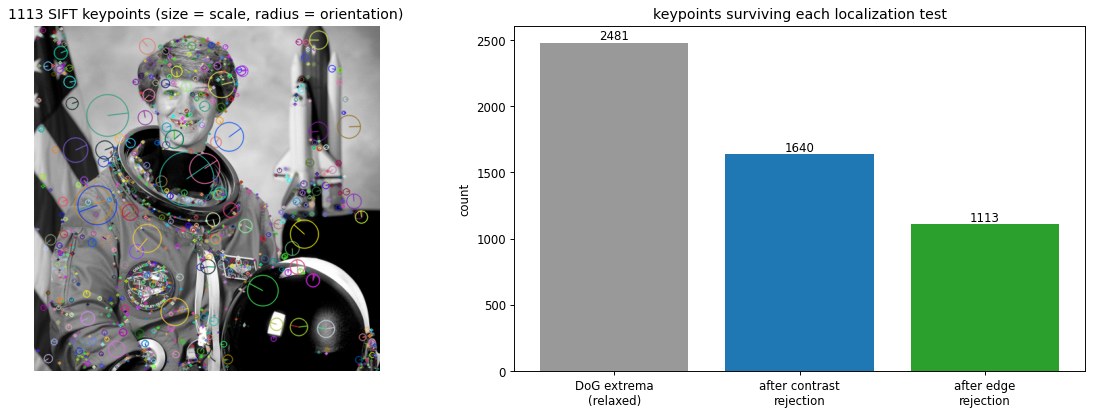

In [11]:
gray = to_u8(load_gray(data.astronaut()))

sift = cv2.SIFT_create()
kps  = sift.detect(gray, None)
rich = cv2.drawKeypoints(gray, kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# localization cascade: contrast rejection, then edge rejection
stages = {
    'DoG extrema\n(relaxed)':    cv2.SIFT_create(contrastThreshold=0.01, edgeThreshold=100),
    'after contrast\nrejection': cv2.SIFT_create(contrastThreshold=0.04, edgeThreshold=100),
    'after edge\nrejection':     cv2.SIFT_create(contrastThreshold=0.04, edgeThreshold=10),
}
counts = [len(s.detect(gray, None)) for s in stages.values()]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(rich); ax[0].axis('off')
ax[0].set_title(f'{len(kps)} SIFT keypoints (size = scale, radius = orientation)')
bars = ax[1].bar(list(stages.keys()), counts, color=['0.6', 'C0', 'C2'])
for b, cnt in zip(bars, counts):
    ax[1].text(b.get_x() + b.get_width() / 2, cnt + 20, str(cnt), ha='center')
ax[1].set_title('keypoints surviving each localization test'); ax[1].set_ylabel('count')
plt.tight_layout(); plt.show()

## 7. Application: matching and stitching

Because the same physical point yields nearly the same descriptor across views, images can be matched by comparing descriptors. A robust rule is the **ratio test**: keep a match only if the nearest descriptor is clearly closer than the second nearest. The surviving pairs then drive alignment tasks such as panorama stitching.

Below the astronaut image is rotated and scaled to make a second view, and SIFT recovers the correspondences.

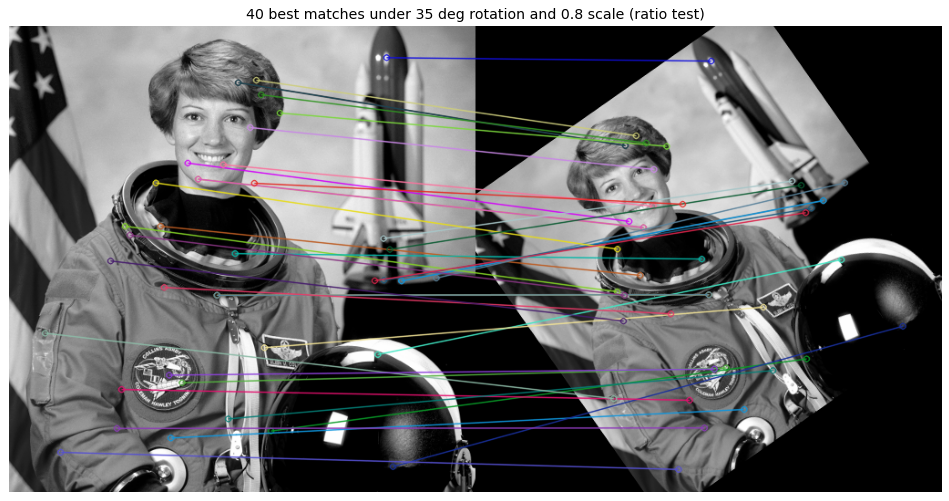

In [12]:
gray = to_u8(load_gray(data.astronaut()))
h, w = gray.shape
M = cv2.getRotationMatrix2D((w / 2, h / 2), 35, 0.8)     # rotate 35 deg, scale 0.8
view2 = cv2.warpAffine(gray, M, (w, h))

sift = cv2.SIFT_create()
k1, d1 = sift.detectAndCompute(gray,  None)
k2, d2 = sift.detectAndCompute(view2, None)

matches = cv2.BFMatcher().knnMatch(d1, d2, k=2)
good = [m for m, nxt in matches if m.distance < 0.7 * nxt.distance]     # Lowe's ratio test
good = sorted(good, key=lambda m: m.distance)[:40]

vis = cv2.drawMatches(gray, k1, view2, k2, good, None,
                      flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(vis); ax.axis('off')
ax.set_title(f'{len(good)} best matches under 35 deg rotation and 0.8 scale (ratio test)')
plt.tight_layout(); plt.show()

## 8. Variants: SURF, MOPS and GLOH

Later descriptors trade some of SIFT's invariance for speed, or change how the gradients are pooled.

- **SURF** (Speeded Up Robust Features) replaces Gaussian derivatives with **box filters** evaluated through an integral image, so a filter of any size costs a constant number of lookups. Orientation comes from **Haar wavelet** responses. SURF is roughly three times faster than SIFT and handles blur well, but is a little weaker under illumination and viewpoint change.
- **MOPS** (Multiscale Oriented Patches) rotates each patch to its dominant gradient orientation, putting every patch in a **canonical orientation** before it is described.
- **GLOH** (Gradient Location-Orientation Histogram) pools gradients in a **log-polar** grid (17 spatial bins, 16 orientation bins) instead of a square grid, giving a 272-D histogram that PCA reduces to 128-D.

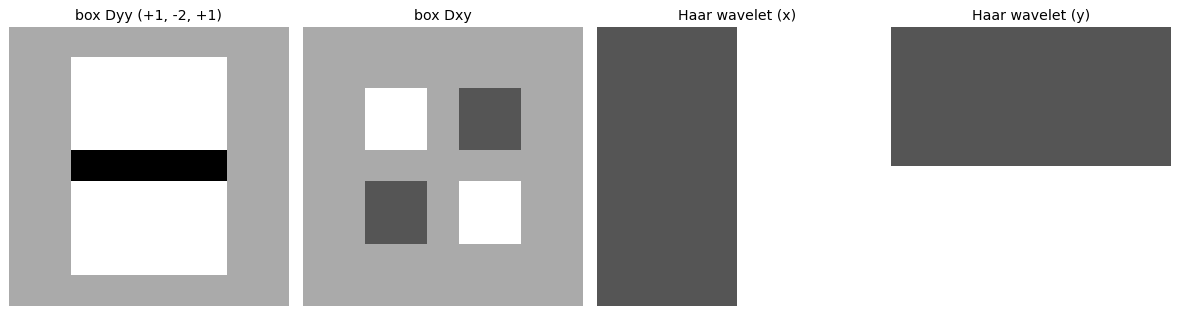

box sum via integral image 10693.60  vs  direct 10693.60   (4 lookups, any size)


In [13]:
# SURF uses box filters and Haar wavelets in place of Gaussian derivatives
def box_template(shape, boxes):                 # boxes: list of (y0, x0, y1, x1, weight)
    t = np.zeros(shape)
    for y0, x0, y1, x1, wv in boxes:
        t[y0:y1, x0:x1] += wv
    return t

Dyy    = box_template((9, 9), [(1, 2, 4, 7, 1), (4, 2, 5, 7, -2), (5, 2, 8, 7, 1)])
Dxy    = box_template((9, 9), [(2, 2, 4, 4, 1), (5, 5, 7, 7, 1), (2, 5, 4, 7, -1), (5, 2, 7, 4, -1)])
haar_x = box_template((8, 8), [(0, 0, 8, 4, -1), (0, 4, 8, 8, 1)])
haar_y = box_template((8, 8), [(0, 0, 4, 8, -1), (4, 0, 8, 8, 1)])

fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
for a, t, name in [(ax[0], Dyy, 'box Dyy (+1, -2, +1)'), (ax[1], Dxy, 'box Dxy'),
                   (ax[2], haar_x, 'Haar wavelet (x)'), (ax[3], haar_y, 'Haar wavelet (y)')]:
    a.imshow(t, cmap='gray', vmin=-2, vmax=1); a.set_title(name); a.axis('off')
plt.tight_layout(); plt.show()

# an integral image returns any box sum in 4 lookups, so filter cost is independent of size
im = load_gray(data.camera())
integral = np.pad(im.cumsum(0).cumsum(1), ((1, 0), (1, 0)))
y0, x0, y1, x1 = 40, 60, 180, 210
via_ii = integral[y1 + 1, x1 + 1] - integral[y0, x1 + 1] - integral[y1 + 1, x0] + integral[y0, x0]
print(f'box sum via integral image {via_ii:.2f}  vs  direct {im[y0:y1 + 1, x0:x1 + 1].sum():.2f}   (4 lookups, any size)')

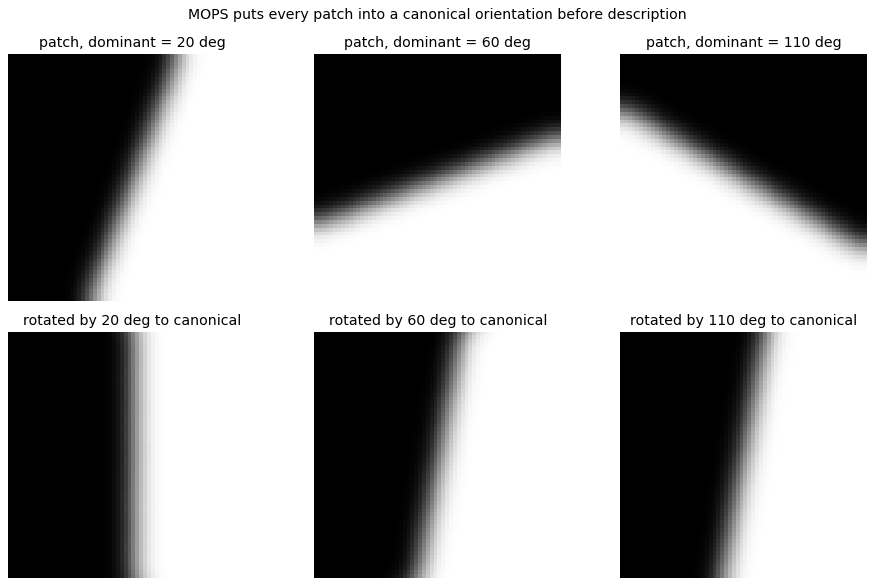

In [14]:
# MOPS: rotate each patch to its dominant orientation so description is rotation invariant
def dominant_orientation(patch):
    return ori_histogram(patch, nbins=36, sigma=patch.shape[0] / 3).argmax() * 10

samples = [step_patch(64, 20), step_patch(64, 70), step_patch(64, 120)]
fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for j, p in enumerate(samples):
    d = dominant_orientation(p)
    canon = ndi.rotate(p, d, reshape=False, order=1, mode='reflect')
    show(ax[0, j], p,     f'patch, dominant = {d} deg')
    show(ax[1, j], canon, f'rotated by {d} deg to canonical')
fig.suptitle('MOPS puts every patch into a canonical orientation before description')
plt.tight_layout(); plt.show()

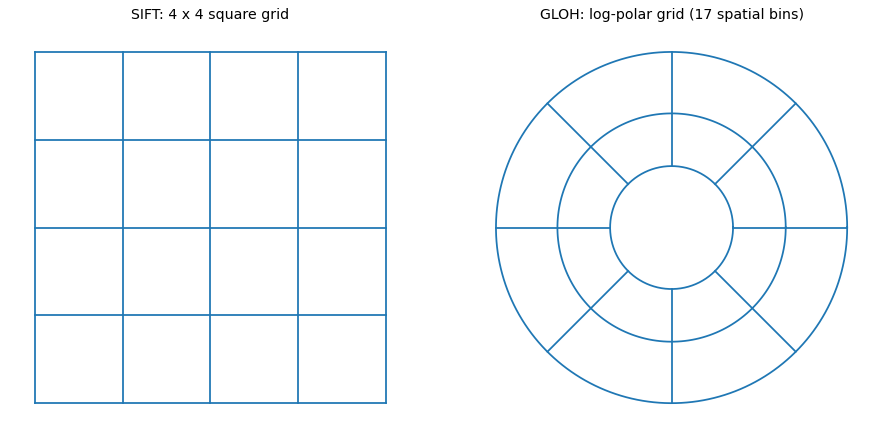

In [15]:
# GLOH pools gradients in a log-polar grid instead of SIFT's square grid
fig, ax = plt.subplots(1, 2, figsize=(11, 5.2), subplot_kw={'aspect': 'equal'})

ax[0].set_title('SIFT: 4 x 4 square grid')
for i in range(5):
    ax[0].plot([i, i], [0, 4], 'C0'); ax[0].plot([0, 4], [i, i], 'C0')
ax[0].set_xlim(-0.3, 4.3); ax[0].set_ylim(-0.3, 4.3); ax[0].axis('off')

# log-polar: a central disk + two outer rings each split into 8 sectors -> 1 + 8 + 8 = 17 spatial bins
ax[1].set_title('GLOH: log-polar grid (17 spatial bins)')
radii = [0.35, 0.65, 1.0]; theta = np.linspace(0, 2 * np.pi, 200)
for rr in radii:
    ax[1].plot(rr * np.cos(theta), rr * np.sin(theta), 'C0')
for a in np.linspace(0, 2 * np.pi, 9)[:-1]:     # sector lines only outside the central disk
    ax[1].plot([radii[0] * np.cos(a), np.cos(a)], [radii[0] * np.sin(a), np.sin(a)], 'C0')
ax[1].set_xlim(-1.15, 1.15); ax[1].set_ylim(-1.15, 1.15); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 9. Explore and verify

SIFT's descriptor is specified precisely enough to test: 128 dimensions, unit norm, and
an orientation estimate that tracks the patch as it rotates. We check all three, then
sweep the patch orientation.

In [16]:
# Verify the descriptor specification.  sift_descriptor returns (vector, cells).
patch16 = step_patch(16, 30)

d, cells = sift_descriptor(patch16)
assert d.shape == (128,), f'descriptor is {d.shape}, expected (128,)'
assert cells.shape == (4, 4, 8), f'cell grid is {cells.shape}, expected (4, 4, 8)'
assert abs(np.linalg.norm(d) - 1.0) < 1e-6, 'descriptor is not unit norm'

# The dominant orientation should follow the patch as we rotate it.
errors = []
for angle in (0, 30, 60, 90, 120):
    est = dominant_orientation(step_patch(32, angle))
    err = min(abs(est - angle) % 360, 360 - abs(est - angle) % 360)
    errors.append(err)
    print(f'  patch at {angle:3d}°  ->  estimated {est:6.1f}°   (error {err:5.1f}°)')

print(f'\ndescriptor: {d.shape[0]} dimensions = 4x4 cells x 8 bins, norm = {np.linalg.norm(d):.6f}')
print(f'orientation error, worst case = {max(errors):.1f} degrees')

  patch at   0°  ->  estimated    0.0°   (error   0.0°)
  patch at  30°  ->  estimated   20.0°   (error  10.0°)
  patch at  60°  ->  estimated   60.0°   (error   0.0°)
  patch at  90°  ->  estimated   80.0°   (error  10.0°)
  patch at 120°  ->  estimated  110.0°   (error  10.0°)

descriptor: 128 dimensions = 4x4 cells x 8 bins, norm = 1.000000
orientation error, worst case = 10.0 degrees


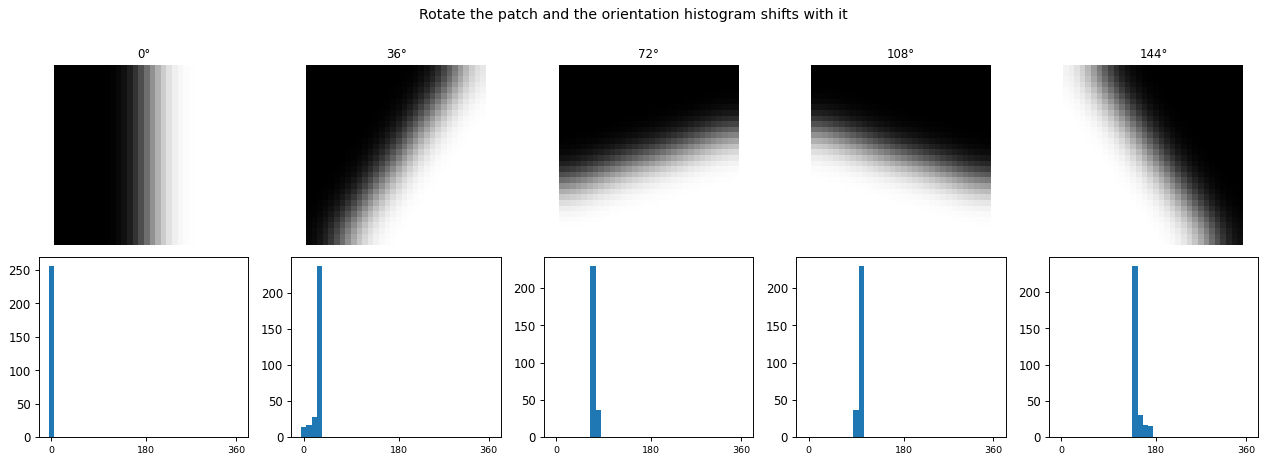

In [17]:
# Static sweep: the orientation histogram rotates with the patch.
fig, ax = plt.subplots(2, 5, figsize=(15, 5.4))
for j, angle in enumerate([0, 36, 72, 108, 144]):
    p = step_patch(32, angle)
    h = ori_histogram(p)
    ax[0, j].imshow(p, cmap='gray'); ax[0, j].set_axis_off()
    ax[0, j].set_title(f'{angle}°', fontsize=10)
    ax[1, j].bar(np.arange(len(h)), h, width=1.0)
    ax[1, j].set_xticks([0, len(h) // 2, len(h) - 1])
    ax[1, j].set_xticklabels(['0', '180', '360'], fontsize=8)
fig.suptitle('Rotate the patch and the orientation histogram shifts with it', y=1.0)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [18]:
# Live: rotate the patch and watch the peak move.
from ipywidgets import interact, IntSlider

def orient(angle=30):
    p = step_patch(32, angle)
    h = ori_histogram(p)
    est = dominant_orientation(p)
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
    ax[0].imshow(p, cmap='gray'); ax[0].set_axis_off(); ax[0].set_title(f'patch at {angle}°')
    ax[1].bar(np.arange(len(h)), h, width=1.0)
    ax[1].set_title(f'orientation histogram (estimate {est:.0f}°)')
    plt.tight_layout(); plt.show()

interact(orient, angle=IntSlider(min=0, max=170, step=10, value=30));

interactive(children=(IntSlider(value=30, description='angle', max=170, step=10), Output()), _dom_classes=('wi…

---

## Key takeaways

| Stage | Key idea |
|---|---|
| Scale-space extrema | DoG across scale approximates the scale-normalized LoG; keep strict extrema of the $3\times3\times3$ neighborhood (26 neighbors) |
| Keypoint localization | Quadratic fit for sub-pixel location; reject low contrast ($\lvert D\rvert < 0.03$) and edges ($\mathrm{Tr}(H)^2/\det(H) > (r+1)^2/r$, $r=10$) |
| Orientation | Peak of a magnitude-weighted 36-bin gradient histogram; a second peak within 80% adds a keypoint |
| Descriptor | $4\times4$ cells of 8-bin histograms over a $16\times16$ window = 128-D; unit norm, clip at 0.2, renormalize |
| SURF | Box filters via integral images and Haar wavelets: about 3x faster than SIFT |
| MOPS | Rotate the patch to a canonical orientation before describing it |
| GLOH | Log-polar pooling (272-D) reduced to 128-D with PCA |

**Reading:** Lowe, *Distinctive Image Features from Scale-Invariant Keypoints*, IJCV 2004. Szeliski, *Computer Vision: Algorithms and Applications*, Section 3.5. OpenCV: [Introduction to SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html).

**To think about:** Which descriptor performs better, SIFT or MOPS, and on what kind of image? Why is the SIFT descriptor more distinctive than a raw Harris corner? What would break if the orientation-assignment step were removed?

## Exercises

1. **Contrast threshold versus keypoint count.** Sweep the $|D| < 0.03$ rejection threshold and plot how many keypoints survive. What is lost at the aggressive end?

2. **Test the invariance claim.** Rotate an image by 45 degrees and scale it by 1.5, match SIFT descriptors back to the original, and report the fraction of correct matches.

3. **The ratio test.** Implement Lowe's nearest/second-nearest ratio test and sweep the ratio. Plot correct against incorrect matches and justify the usual 0.8.

4. **Stitch two images.** Match keypoints across an overlapping pair, fit a homography with RANSAC, and warp one onto the other. Where does it fail if the overlap is small?